/home/marta/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


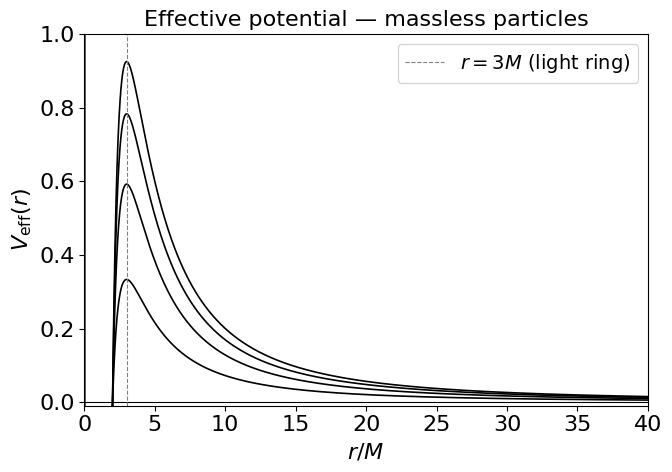

In [1]:
import numpy as np
import matplotlib.pyplot as plt

M = 1
FONTSIZE = 16  

r = np.linspace(-150, 150, 50000)

def V_massless(r, L):
    return (1 - 2*M/r) * L**2 / r**2

L_values = [
    (3*M,   r'$L = 3M$'),
    (4*M,   r'$L = 4M$'),
    (4.6*M, r'$L = 4.6M$'),
    (5*M,   r'$L = 5M$'),
]

plt.rcParams.update({'font.size': FONTSIZE})

fig, ax = plt.subplots(figsize=(7, 5))

for L, label in L_values:
    V = V_massless(r, L)
    ax.plot(r, V, color='black', linewidth=1.2)
    idx_max = np.argmax(V)
    ax.plot(r[idx_max], V[idx_max], 'ko', markersize=3)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(3*M, color='gray', linestyle='--', linewidth=0.8,
           label=r'$r = 3M$ (light ring)')

ax.set_xlim(0, 40)
ax.set_ylim(-0.01, 1)
ax.set_xlabel(r'$r/M$',              fontsize=FONTSIZE)
ax.set_ylabel(r'$V_{\rm eff}(r)$',   fontsize=FONTSIZE)
ax.set_title(r'Effective potential — massless particles', fontsize=FONTSIZE)
ax.legend(fontsize=14, loc='upper right')
ax.tick_params(labelsize=FONTSIZE)
ax.grid(False)

plt.tight_layout()
plt.savefig('Veff_massless.pdf', dpi=150)
plt.show()

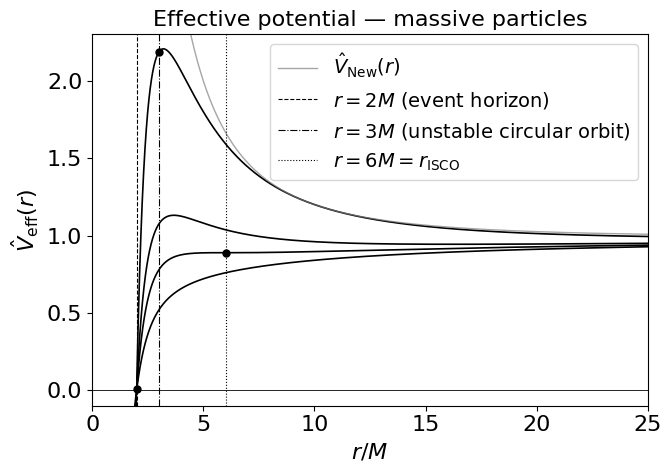

In [2]:
import numpy as np
import matplotlib.pyplot as plt

M = 1

def V_massive(r, L2):
    return (1 - 2*M/r) * (1 + L2/r**2)

def V_newtonian(r, L2):
    return -M/r + L2/(2*r**2) + 1

r_in   = np.linspace(0.1,  1.99, 20000)
r_out  = np.linspace(2.01, 40,   20000)
r_newt = np.linspace(2.01, 40,   20000)

cases = [
    (5 * M**2, r'$\hat{L}^2 < 12M^2$'),
    (12 * M**2, r'$\hat{L}^2 = 12M^2$'),
    (20 * M**2, r'$\hat{L}^2 > 12M^2$'),
    (50 * M**2, r'$\hat{L}^2 \gg 12M^2$'),
]

plt.rcParams.update({'font.size': FONTSIZE})

fig, ax = plt.subplots(figsize=(7,5))

for L2, label in cases:
    ax.plot(r_in,  V_massive(r_in,  L2), color='black', linewidth=1.2)
    ax.plot(r_out, V_massive(r_out, L2), color='black', linewidth=1.2)

L2_large = 60 * M**2
ax.plot(r_newt, V_newtonian(r_newt, L2_large),
        color='gray', linewidth=1.0, linestyle='-', alpha=0.7,
        label=r'$\hat{V}_{\rm New}(r)$')

ax.plot(2.01,   V_massive(2.01,    5*M**2), 'ko', markersize=5)
ax.plot(6*M,    V_massive(6*M,     12*M**2), 'ko', markersize=5)
ax.plot(3*M,    V_massive(3*M,     50*M**2), 'ko', markersize=5)

ax.axvline(2*M, color='black', linestyle='--',      linewidth=0.8,
           label=r'$r = 2M$ (event horizon)')
ax.axvline(3*M, color='black', linestyle='dashdot', linewidth=0.8,
           label=r'$r = 3M$ (unstable circular orbit)')
ax.axvline(6*M, color='black', linestyle='dotted',  linewidth=0.8,
           label=r'$r = 6M = r_{\rm ISCO}$')
ax.axhline(0,   color='black', linewidth=0.6)

ax.set_xlim(0, 25)
ax.set_ylim(-0.1, 2.3)
ax.set_xlabel(r'$r/M$',              fontsize=FONTSIZE)
ax.set_ylabel(r'$\hat{V}_{\rm eff}(r)$', fontsize=FONTSIZE)
ax.set_title(r'Effective potential — massive particles', fontsize=FONTSIZE)
ax.legend(fontsize=14, loc='upper right', frameon=True)
ax.tick_params(labelsize=FONTSIZE)
ax.grid(False)

plt.tight_layout()
plt.savefig('Veff_massive.pdf', dpi=150)
plt.show()